## Model Development - Demo Version

In [1]:
pip install torch

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import os

from model import TabTransformer, ImprovedTabTransformer

## 1. Load data & Preprocessing

In [27]:
# --- 1. Load Data ---
## df = pd.read_excel("../data/data_demo.xlsx")
df_orig = pd.read_excel("../data/data_final_revision.xlsx")

In [28]:
df_orig.columns

Index(['url', 'filename', 'first_partner_gender', 'first_partner_age_bin',
       'second_partner_gender', 'second_partner_age_bin',
       'first_partner_school_category', 'second_partner_school_category',
       'first_partner_level_id', 'second_partner_level_id',
       'first_partner_field', 'second_partner_field', 'how_first_met_category',
       'first_partner_is_graduate', 'second_partner_is_graduate'],
      dtype='object')

## Encode categorical features

In [ ]:

df_A2B = df_orig.rename(columns={
    'first_partner_gender': 'partner_gender',
    'first_partner_age_bin': 'partner_age_bin',
    'first_partner_school_category': 'partner_school_category',
    'first_partner_level_id': 'partner_level_id',
    'first_partner_field': 'partner_field',
    'first_partner_is_graduate': 'partner_is_graduate',
    'second_partner_gender': 'target_gender',
    'second_partner_age_bin': 'target_age_bin',
    'second_partner_school_category': 'target_school_category',
    'second_partner_level_id': 'target_level_id',
    'second_partner_field': 'target_field'
})

df_B2A = df_orig.rename(columns={
    'second_partner_gender': 'partner_gender',
    'second_partner_age_bin': 'partner_age_bin',
    'second_partner_school_category': 'partner_school_category',
    'second_partner_level_id': 'partner_level_id',
    'second_partner_field': 'partner_field',
    'second_partner_is_graduate': 'partner_is_graduate',
    'first_partner_gender': 'target_gender',
    'first_partner_age_bin': 'target_age_bin',
    'first_partner_school_category': 'target_school_category',
    'first_partner_level_id': 'target_level_id',
    'first_partner_field': 'target_field'
})

df = pd.concat([df_A2B, df_B2A], ignore_index=True)

In [ ]:
input_cols = ['partner_gender', 'partner_age_bin', 'partner_school_category',
              'partner_level_id', 'partner_field', 'partner_is_graduate']
output_cols = ['target_gender', 'target_age_bin', 'target_school_category',
               'target_level_id', 'target_field']
columns_to_encode = input_cols + output_cols

# Encode

label_encoders = {}

gender_classes = ['Male', 'Female', 'Nonbinary', 'Unknown']

for col in columns_to_encode:
    df[col] = df[col].replace('Not mentioned', 'Unknown').astype(str).str.strip()

    le = LabelEncoder()

    if col in ['partner_gender', 'target_gender']:
        df[col] = df[col].apply(lambda x: x if x in gender_classes else 'Unknown')
        le.classes_ = np.array(gender_classes)  
        df[col] = le.transform(df[col])
    else:
        df[col] = le.fit_transform(df[col])
    
    label_encoders[col] = le

## Split Data

In [33]:
# Split data
X_train, X_test, Y_train, Y_test = train_test_split(
    df[input_cols].values,
    df[output_cols].values,
    test_size=0.2,
    random_state=42
)

X_train = torch.tensor(X_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.long)
Y_train = torch.tensor(Y_train, dtype=torch.long)
Y_test = torch.tensor(Y_test, dtype=torch.long)

## Train and test datasets

In [34]:
# initialize 
input_cardinality = [df[col].nunique() for col in input_cols]
output_cardinality = [df[col].nunique() for col in output_cols]

# model
model = ImprovedTabTransformer(
    category_sizes=input_cardinality,
    dim=64,  
    output_sizes=output_cardinality
)



In [35]:
# Train the model
from torch.optim import AdamW
criterions = [nn.CrossEntropyLoss() for _ in output_cols]
# optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
optimizer = optim.AdamW(model.parameters(), lr=0.001)


def augment_batch(batch_X, mask_prob=0.2):
    mask = torch.rand_like(batch_X.float()) < mask_prob
    # Replace with "unknown" token (assuming 0 is unused/unknown)
    return torch.where(mask, torch.zeros_like(batch_X), batch_X)


def train(model, X, Y, epochs=15, batch_size=64):
    model.train()
    for epoch in range(epochs):
        permutation = torch.randperm(X.size()[0])
        total_loss = 0

        for i in range(0, X.size()[0], batch_size):
            indices = permutation[i:i+batch_size]
            batch_X, batch_Y = X[indices], Y[indices]
            batch_X = augment_batch(batch_X)

            optimizer.zero_grad()
            outputs = model(batch_X)

            losses = [
                criterions[j](outputs[j], batch_Y[:, j])
                for j in range(len(output_cols))
            ]
            loss = sum(losses)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f'Epoch {epoch+1}, Loss: {total_loss / len(X)}')
        
train(model, X_train, Y_train)

Epoch 1, Loss: 0.11192884683430003
Epoch 2, Loss: 0.1057692075311084
Epoch 3, Loss: 0.10501747422312382
Epoch 4, Loss: 0.10428557865579464
Epoch 5, Loss: 0.10370149915759111
Epoch 6, Loss: 0.10373654703045614
Epoch 7, Loss: 0.10332873946334321
Epoch 8, Loss: 0.10311758131730614
Epoch 9, Loss: 0.10273291807387536
Epoch 10, Loss: 0.1028103177827842
Epoch 11, Loss: 0.10259168470738227
Epoch 12, Loss: 0.10249230466387914
Epoch 13, Loss: 0.10246564152216181
Epoch 14, Loss: 0.10235776192384745
Epoch 15, Loss: 0.10230793561408824


In [36]:
# --- 8. Evaluation ---
def evaluate(model, X, Y):
    model.eval()
    with torch.no_grad():
        outputs = model(X)
        correct = 0
        total = 0
        for j in range(len(output_cols)):
            _, predicted = torch.max(outputs[j].data, 1)
            correct += (predicted == Y[:, j]).sum().item()
            total += Y.size(0)
        accuracy = correct / total
        print(f'Accuracy: {accuracy:.4f}')

evaluate(model, X_test, Y_test)

Accuracy: 0.5580


In [37]:
def evaluate(model, X, Y):
    model.eval()
    with torch.no_grad():
        outputs = model(X)
        total_acc = 0
        feature_acc = []

        for j in range(len(output_cols)):
            _, predicted = torch.max(outputs[j].data, 1)
            correct = (predicted == Y[:, j]).sum().item()
            acc = correct / Y.size(0)
            feature_acc.append(acc)
            total_acc += acc

        avg_acc = total_acc / len(output_cols)
        print(f'Average Accuracy: {avg_acc:.4f}')
        for col, acc in zip(output_cols, feature_acc):
            print(f'{col}: {acc:.4f}')

evaluate(model, X_test, Y_test)

Average Accuracy: 0.5580
target_gender: 0.8376
target_age_bin: 0.6304
target_school_category: 0.5127
target_level_id: 0.4535
target_field: 0.3560


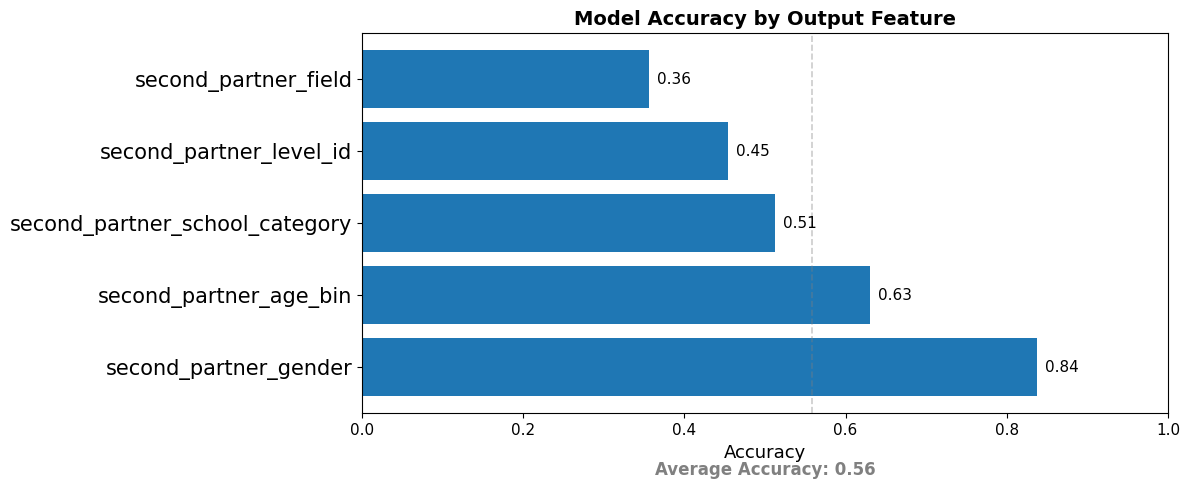

In [38]:
import matplotlib.pyplot as plt

output_fields = [
    "second_partner_gender",
    "second_partner_age_bin",
    "second_partner_school_category",
    "second_partner_level_id",
    "second_partner_field"
]
accuracies = [0.8376, 0.6304, 0.5127, 0.4535, 0.3560]
avg_accuracy = sum(accuracies) / len(accuracies)

plt.figure(figsize=(12, 5))
bars = plt.barh(output_fields, accuracies, color='#1f77b4')  
plt.xlabel("Accuracy", fontsize=13)
plt.title("Model Accuracy by Output Feature", fontsize=14, fontweight='bold')
plt.xticks(fontsize=11)
plt.yticks(fontsize=15)
plt.xlim(0, 1)

for bar, acc in zip(bars, accuracies):
    plt.text(acc + 0.01, bar.get_y() + bar.get_height()/2,
             f"{acc:.2f}", va='center', fontsize=11)

plt.axvline(x=avg_accuracy, color='gray', linestyle='--', linewidth=1.2, alpha=0.4)

plt.text(0.5, -0.15, f"Average Accuracy: {avg_accuracy:.2f}",
         ha='center', va='center', transform=plt.gca().transAxes,
         fontsize=12, fontweight='bold', color='gray')

plt.tight_layout()
plt.show()

### Sample Test - The easiest one to goo...

In [ ]:
def predict_partner(sample_row, model, label_encoders):
    """
    Predict partner attributes from a sample input row (6 features)

    Args:
        sample_row: List of [gender, age_bin, school_category, level_id, field, is_graduate]
        model: Trained TabTransformer model
        label_encoders: Dictionary of fitted LabelEncoders

    Returns:
        Dictionary of predicted attributes
    """
    # Ensure the model is in evaluation mode
    model.eval()

    # Step 1: Prepare input with all required features
    expected_len = 6
    if len(sample_row) != expected_len:
        raise ValueError(f"Input row must contain {expected_len} features: [gender, age_bin, school_category, level_id, field, is_graduate]")

    # Step 2: Define input column names (must match your training input_cols)
    input_cols = [
        'partner_gender',
        'partner_age_bin',
        'partner_school_category',
        'partner_level_id',
        'partner_field',
        'partner_is_graduate'
    ]

    # Step 3: Encode each feature using its LabelEncoder
    try:
        encoded_sample = []
        for col, value in zip(input_cols, sample_row):
            value_str = str(value).strip() if value is not None else 'Unknown'

            if value_str not in label_encoders[col].classes_:
                default_value = label_encoders[col].classes_[0]
                print(f"Warning: Unknown value '{value_str}' for {col}, using '{default_value}' instead")
                value_str = default_value

            encoded_val = label_encoders[col].transform([value_str])[0]
            encoded_sample.append(encoded_val)

    except Exception as e:
        print(f"Encoding error: {e}")
        return None

    # Step 4: Convert to tensor and add batch dimension
    import torch
    sample_tensor = torch.tensor([encoded_sample], dtype=torch.long)

    # Step 5: Get predictions from model
    with torch.no_grad():
        output_preds = model(sample_tensor)

    # Step 6: Decode model outputs
    output_cols = [
        'target_gender',
        'target_age_bin',
        'target_school_category',
        'target_level_id',
        'target_field'
    ]

    predictions = {}
    for i, col in enumerate(output_cols):
        pred_class = torch.argmax(output_preds[i], dim=1).item()
        predictions[col] = label_encoders[col].inverse_transform([pred_class])[0]

    return predictions

In [43]:
sample_row = [
    'Female',                       # partner_gender
    '30-34',                        # partner_age_bin
    'Ivy League',                   # partner_school_category
    'S4',                           # partner_level_id
    'Business and Financial Occupations',  # partner_field
    '1'                             # partner_is_graduate (as string to match encoder)
]

predictions = predict_partner(sample_row, model, label_encoders)

if predictions:
    print("\n=== Predicted Partner Profile ===")
    print(f"Gender:         {predictions['target_gender']}")
    print(f"Age Group:      {predictions['target_age_bin']}")
    print(f"School Category: {predictions['target_school_category']}")
    print(f"Education Level: {predictions['target_level_id']}")
    print(f"Field of Study:  {predictions['target_field']}")



=== Predicted Partner Profile ===
Gender:         Male
Age Group:      30-34
School Category: Other Colleges
Education Level: S5
Field of Study:  Business and Financial Occupations


In [49]:
sample_row_2 = [
    'Male',
    '25-29',
    'Top 50 Private (Non-Ivy)',
    'S3',
    'Architecture and Engineering Occupations',
    '0'  # not graduate
]

predictions = predict_partner(sample_row_2, model, label_encoders)

if predictions:
    print("\n=== Predicted Partner Profile ===")
    print(f"Gender:         {predictions['target_gender']}")
    print(f"Age Group:      {predictions['target_age_bin']}")
    print(f"School Category: {predictions['target_school_category']}")
    print(f"Education Level: {predictions['target_level_id']}")
    print(f"Field of Study:  {predictions['target_field']}")


=== Predicted Partner Profile ===
Gender:         Female
Age Group:      25-29
School Category: Top 50 Private (Non-Ivy)
Education Level: S4
Field of Study:  Business and Financial Occupations


In [51]:
sample_row_3 = [
    'Female',
    '35-39',
    'Top 50 Private (Non-Ivy)',
    'S5',
    'Arts and Design Occupations',
    '1'
]

predictions = predict_partner(sample_row_3, model, label_encoders)

if predictions:
    print("\n=== Predicted Partner Profile ===")
    print(f"Gender:         {predictions['target_gender']}")
    print(f"Age Group:      {predictions['target_age_bin']}")
    print(f"School Category: {predictions['target_school_category']}")
    print(f"Education Level: {predictions['target_level_id']}")
    print(f"Field of Study:  {predictions['target_field']}")


=== Predicted Partner Profile ===
Gender:         Male
Age Group:      40-44
School Category: Other Colleges
Education Level: S5
Field of Study:  Arts and Design Occupations


In [55]:
sample_row_4 = [
    'Nonbinary',
    '30-34',
    'Other Colleges',
    'S5',
    'Media and Communication Occupations',
    '1'
]

predictions = predict_partner(sample_row_4, model, label_encoders)

if predictions:
    print("\n=== Predicted Partner Profile ===")
    print(f"Gender:         {predictions['target_gender']}")
    print(f"Age Group:      {predictions['target_age_bin']}")
    print(f"School Category: {predictions['target_school_category']}")
    print(f"Education Level: {predictions['target_level_id']}")
    print(f"Field of Study:  {predictions['target_field']}")


=== Predicted Partner Profile ===
Gender:         Female
Age Group:      30-34
School Category: Other Colleges
Education Level: S5
Field of Study:  Media and Communication Occupations


## Baseline Model

- TODO (?): Compare with a simple MLP
- More for report purpose
  
